In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

Cell 1: Check the dataset path and files :

In [1]:
import os, re
import numpy as np
from pathlib import Path
from collections import Counter
from PIL import Image

BASE = Path("/kaggle/input/datasets/saikotahmed/imd2020/IMD2020")
print("Base exists:", BASE.exists())
if not BASE.exists():
    print("Not found. Searching /kaggle/input for the Authentic folder ...")
    for root, dirs, _ in os.walk("/kaggle/input"):
        if "Authentic" in dirs:
            print("  found dataset root:", root)
            break
    raise FileNotFoundError("Fix BASE above to the path printed here, then re-run.")

authentic_dir, fake_dir, mask_dir = BASE / "Authentic", BASE / "img", BASE / "mask"
authentic_files = sorted(p for p in authentic_dir.rglob("*") if p.is_file())
fake_files      = sorted(p for p in fake_dir.rglob("*") if p.is_file())
mask_files      = sorted(p for p in mask_dir.rglob("*") if p.is_file())

for name, files in [("Authentic", authentic_files), ("img (fake)", fake_files), ("mask", mask_files)]:
    exts = dict(Counter(p.suffix.lower() for p in files))
    print(f"{name:10s}: {len(files):5d} files | extensions {exts} | e.g. {files[0].name}")

# Pairing rule: mask name = fake name + "_mask"
mask_stems = {p.stem for p in mask_files}
missing = [p.name for p in fake_files if f"{p.stem}_mask" not in mask_stems]
print("\nForged images without a mask:", len(missing), missing[:5])

# Sizes and mask values
print("\nSample sizes:")
for p in [authentic_files[0], fake_files[0], mask_files[0]]:
    im = Image.open(p)
    print(f"  {p.name:28s} size={im.size} mode={im.mode}")
m = np.array(Image.open(mask_files[0]).convert("L"))
print("Mask unique values:", np.unique(m), "| tampered pixels: %.2f%%" % (100 * (m > 127).mean()))

Base exists: True
Authentic :   414 files | extensions {'.jpg': 414} | e.g. 00006_orig.jpg
img (fake):  2010 files | extensions {'.jpg': 1813, '.png': 197} | e.g. 00006_fake.jpg
mask      :  2010 files | extensions {'.png': 2010} | e.g. 00006_fake_mask.png

Forged images without a mask: 0 []

Sample sizes:
  00006_orig.jpg               size=(1368, 953) mode=RGB
  00006_fake.jpg               size=(1200, 836) mode=RGB
  00006_fake_mask.png          size=(1200, 836) mode=RGB
Mask unique values: [  0 255] | tampered pixels: 3.72%


Cell 2: Full setup (trains nothing)
Imports, builds the train/val/test split (80/10/10, grouped by source image), the patch datasets and loaders, the models, the training and evaluation functions, and make_bundle(). Expected split: test 41/203, train 331/1606, val 42/201, and 0 0 0 shared base IDs.

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import re, csv, time, copy, random, pickle, zipfile, glob
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchmetrics.classification import MulticlassPrecision, MulticlassRecall, MulticlassF1Score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, confusion_matrix,
                             balanced_accuracy_score, roc_auc_score)
from PIL import Image

# ---------------- Reproducibility + device ----------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cpu":
    print("WARNING: no GPU found. Turn on a GPU in Settings -> Accelerator before training.")

# ---------------- Dataset paths ----------------
BASE = Path("/kaggle/input/datasets/saikotahmed/imd2020/IMD2020")
authentic_dir, fake_dir, mask_dir = BASE / "Authentic", BASE / "img", BASE / "mask"
authentic_files = sorted(p for p in authentic_dir.rglob("*") if p.is_file())
fake_files      = sorted(p for p in fake_dir.rglob("*") if p.is_file())

def base_id(stem):
    return re.sub(r"_(fake|orig)(_\d+)?$", "", stem)

# ---------------- Dataframe + group-aware stratified split ----------------
rows = []
for p in authentic_files:
    rows.append({"path": str(p), "label": 0, "class_name": "Authentic", "base_id": base_id(p.stem), "mask_path": None})
for p in fake_files:
    rows.append({"path": str(p), "label": 1, "class_name": "Forged", "base_id": base_id(p.stem),
                 "mask_path": str(mask_dir / f"{p.stem}_mask.png")})
df = pd.DataFrame(rows)

sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED)
folds = [test_idx for _, test_idx in sgkf.split(df, df["label"], groups=df["base_id"])]
df["split"] = "train"
df.loc[folds[0], "split"] = "test"
df.loc[folds[1], "split"] = "val"
df.to_csv("/kaggle/working/split.csv", index=False)

print("\nImages per split / class (expected: test 41/203, train 331/1606, val 42/201):")
print(pd.crosstab(df["split"], df["class_name"], margins=True))
g = {s: set(df.loc[df["split"] == s, "base_id"]) for s in ["train", "val", "test"]}
print("Shared base IDs across splits:", len(g["train"] & g["val"]), len(g["train"] & g["test"]), len(g["val"] & g["test"]))

split_df = {s: df[df["split"] == s].reset_index(drop=True) for s in ["train", "val", "test"]}

# ---------------- Patch datasets ----------------
PATCH, MAX_TILES, TRAIN_REPEAT = 224, 24, 2
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
normalize = transforms.Normalize(mean, std)

def pad_to_patch(arr, patch=PATCH):
    h, w = arr.shape[:2]
    ph, pw = max(0, patch - h), max(0, patch - w)
    if ph or pw:
        arr = np.pad(arr, ((0, ph), (0, pw)) + ((0, 0),) * (arr.ndim - 2), mode="constant")
    return arr

def load_image_and_mask(row):
    img = Image.open(row["path"]).convert("RGB")
    mask = None
    if row["label"] == 1:
        m = Image.open(row["mask_path"]).convert("L")
        if m.size != img.size:
            m = m.resize(img.size, Image.NEAREST)
        mask = pad_to_patch(np.array(m) > 127)
    return pad_to_patch(np.array(img)), mask

def to_norm_tensor(crop):
    t = torch.from_numpy(np.ascontiguousarray(crop)).permute(2, 0, 1).float() / 255.0
    return normalize(t)

def tile_coords(h, w, patch=PATCH, max_tiles=MAX_TILES):
    ys = list(range(0, h - patch + 1, patch)); xs = list(range(0, w - patch + 1, patch))
    if ys[-1] != h - patch: ys.append(h - patch)
    if xs[-1] != w - patch: xs.append(w - patch)
    coords = [(y, x) for y in ys for x in xs]
    if max_tiles is not None and len(coords) > max_tiles:
        idx = np.linspace(0, len(coords) - 1, max_tiles).round().astype(int)
        coords = [coords[i] for i in idx]
    return coords

class TrainPatchDataset(torch.utils.data.Dataset):
    def __init__(self, frame, repeat=TRAIN_REPEAT, p_pos=0.5):
        self.frame, self.repeat, self.p_pos = frame, repeat, p_pos
    def __len__(self):
        return len(self.frame) * self.repeat
    def _rand_xy(self, h, w):
        return random.randint(0, h - PATCH), random.randint(0, w - PATCH)
    def _pos_xy(self, mask):
        h, w = mask.shape
        ys, xs = np.nonzero(mask)
        k = random.randrange(len(ys))
        y = int(np.clip(ys[k] - random.randint(0, PATCH - 1), 0, h - PATCH))
        x = int(np.clip(xs[k] - random.randint(0, PATCH - 1), 0, w - PATCH))
        return y, x
    def _clean_xy(self, mask, tries=10):
        h, w = mask.shape
        for _ in range(tries):
            y, x = self._rand_xy(h, w)
            if not mask[y:y + PATCH, x:x + PATCH].any():
                return y, x
        return None
    def __getitem__(self, i):
        row = self.frame.iloc[i % len(self.frame)]
        img, mask = load_image_and_mask(row)
        h, w = img.shape[:2]
        if row["label"] == 0:
            (y, x), label = self._rand_xy(h, w), 0
        else:
            clean = None if random.random() < self.p_pos else self._clean_xy(mask)
            if clean is None:
                (y, x), label = self._pos_xy(mask), 1
            else:
                (y, x), label = clean, 0
        crop = img[y:y + PATCH, x:x + PATCH]
        if random.random() < 0.5:
            crop = crop[:, ::-1]
        return to_norm_tensor(crop), label

class EvalTileDataset(torch.utils.data.Dataset):
    def __init__(self, frame):
        self.frame = frame
    def __len__(self):
        return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        img = pad_to_patch(np.array(Image.open(row["path"]).convert("RGB")))
        h, w = img.shape[:2]
        tiles = [to_norm_tensor(img[y:y + PATCH, x:x + PATCH]) for y, x in tile_coords(h, w)]
        return torch.stack(tiles), int(row["label"])

def single_item_collate(batch):
    return batch[0]

train_loader_p = DataLoader(TrainPatchDataset(split_df["train"]), batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader_p   = DataLoader(EvalTileDataset(split_df["val"]),  batch_size=1, shuffle=False, num_workers=4, collate_fn=single_item_collate)
test_loader_p  = DataLoader(EvalTileDataset(split_df["test"]), batch_size=1, shuffle=False, num_workers=4, collate_fn=single_item_collate)

# ---------------- Config, loss weights, results store ----------------
FREEZE_BACKBONE, LR, TOPK, NUM_CLASSES = False, 1e-4, 1, 2
frac_forged = 0.433   # share of Forged patches measured earlier (~43%)
patch_weights = torch.tensor([1 / (2 * (1 - frac_forged)), 1 / (2 * frac_forged)], dtype=torch.float32).to(device)
results = {}

# ---------------- Metrics ----------------
def dice_forged(preds, labels):
    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()
    denom = 2 * tp + fp + fn
    return (2 * tp / denom) if denom > 0 else 1.0

def image_scores(model, loader, device, topk=TOPK, chunk=64):
    model.eval()
    scores, img_labels = [], []
    with torch.no_grad():
        for tiles, label in loader:
            probs = []
            for i in range(0, len(tiles), chunk):
                out = model(tiles[i:i + chunk].to(device, non_blocking=True))
                probs.append(torch.softmax(out, 1)[:, 1].cpu())
            probs = torch.cat(probs)
            scores.append(probs.topk(min(topk, len(probs))).values.mean().item())
            img_labels.append(label)
    return np.array(scores), np.array(img_labels)

def metrics_at(scores, y_true, thr):
    y_pred = (scores >= thr).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary', pos_label=1, zero_division=0)
    _, _, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return {"Accuracy": accuracy_score(y_true, y_pred), "Precision": p, "Recall": r, "F1": f1,
            "Dice": dice_forged(torch.tensor(y_pred), torch.tensor(y_true)), "MacroF1": macro_f1,
            "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
            "ConfMatrix": confusion_matrix(y_true, y_pred, labels=[0, 1])}

def tune_threshold(scores, y_true):
    best_thr, best_f1 = 0.5, -1.0
    for thr in np.linspace(0.05, 0.95, 91):
        f = metrics_at(scores, y_true, thr)["MacroF1"]
        if f > best_f1:
            best_f1, best_thr = f, float(thr)
    return best_thr

# ---------------- Models ----------------
def make_head(in_features, num_classes=NUM_CLASSES):
    return nn.Sequential(nn.Linear(in_features, 128), nn.ReLU(), nn.Linear(128, num_classes))

def build_model(name, freeze_backbone=FREEZE_BACKBONE):
    if name == "ResNet50":        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    elif name == "EfficientNet":  model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    elif name == "DenseNet":      model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    elif name == "ConvNeXt":      model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    elif name == "ViT":           model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    else: raise ValueError(f"Unknown model: {name}")
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    if name == "ResNet50":        model.fc = make_head(model.fc.in_features)
    elif name == "EfficientNet":  model.classifier[1] = make_head(model.classifier[1].in_features)
    elif name == "DenseNet":      model.classifier = make_head(model.classifier.in_features)
    elif name == "ConvNeXt":      model.classifier[2] = make_head(model.classifier[2].in_features)
    elif name == "ViT":           model.heads.head = make_head(model.heads.head.in_features)
    return model.to(device)

# ---------------- Training (patch pipeline) ----------------
def train_model_patch(model, model_name, train_loader, val_loader, criterion, optimizer, epochs, device, num_classes=2):
    since = time.time()
    best_val_f1, best_epoch, best_thr = -1.0, 0, 0.5
    best_model_wts = copy.deepcopy(model.state_dict())

    csv_filename = f"/kaggle/working/{model_name}_patch_training_log.csv"
    with open(csv_filename, mode='w', newline='') as file:
        csv.writer(file).writerow(['Epoch', 'Train Loss', 'Train Acc', 'Train Precision', 'Train Recall', 'Train F1',
                                   'Val AUC', 'Val MacroF1@0.5', 'Val Threshold', 'Val MacroF1@thr', 'Val BalAcc@thr',
                                   'Val Precision@thr', 'Val Recall@thr', 'Val F1@thr', 'Val Dice@thr'])

    train_precision = MulticlassPrecision(num_classes=num_classes, average='macro').to(device)
    train_recall = MulticlassRecall(num_classes=num_classes, average='macro').to(device)
    train_f1 = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        all_preds, all_labels = [], []
        for inputs, lbls in train_loader:
            inputs = inputs.to(device).float(); lbls = lbls.to(device).long()
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, lbls)
            loss.backward(); optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += lbls.size(0); correct += (predicted == lbls).sum().item()
            all_preds.append(predicted); all_labels.append(lbls)

        avg_train_loss, train_accuracy = running_loss / total, 100 * correct / total
        all_preds, all_labels = torch.cat(all_preds), torch.cat(all_labels)
        tp_, tr_, tf_ = (train_precision(all_preds, all_labels).item(), train_recall(all_preds, all_labels).item(),
                         train_f1(all_preds, all_labels).item())
        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.2f}%, "
              f"Train Precision: {tp_:.4f}, Train Recall: {tr_:.4f}, Train F1: {tf_:.4f}")

        scores, y_val = image_scores(model, val_loader, device)
        auc = roc_auc_score(y_val, scores)
        m05 = metrics_at(scores, y_val, 0.5)
        thr = tune_threshold(scores, y_val)
        mt = metrics_at(scores, y_val, thr)
        print(f"Epoch [{epoch+1}/{epochs}], Val AUC: {auc:.4f} | MacroF1@0.5: {m05['MacroF1']:.4f} | "
              f"thr={thr:.2f} MacroF1: {mt['MacroF1']:.4f}, BalAcc: {mt['BalancedAcc']:.4f}, "
              f"Precision: {mt['Precision']:.4f}, Recall: {mt['Recall']:.4f}, F1: {mt['F1']:.4f}")

        with open(csv_filename, mode='a', newline='') as file:
            csv.writer(file).writerow([epoch+1, avg_train_loss, train_accuracy, tp_, tr_, tf_, auc, m05['MacroF1'], thr,
                                       mt['MacroF1'], mt['BalancedAcc'], mt['Precision'], mt['Recall'], mt['F1'], mt['Dice']])

        if mt['MacroF1'] > best_val_f1:
            best_val_f1, best_epoch, best_thr = mt['MacroF1'], epoch + 1, thr
            best_model_wts = copy.deepcopy(model.state_dict())
            # save immediately, so an interruption can't lose the best checkpoint
            torch.save({"state_dict": best_model_wts, "threshold": best_thr, "epoch": best_epoch},
                       f"/kaggle/working/best_{model_name}_patch.pth")

    elapsed = time.time() - since
    print(f"Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
    print(f"\n✔️ Best model saved at epoch {best_epoch} with Val MacroF1 {best_val_f1:.4f} (threshold {best_thr:.2f})")
    model.load_state_dict(best_model_wts)
    return model, best_thr

def run_experiment_patch(name, epochs):
    print(f"\n{'='*20} {name} (patch pipeline) {'='*20}")
    model = build_model(name, freeze_backbone=FREEZE_BACKBONE)
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total params: {total_params:,} | Trainable params: {trainable_params:,}")

    criterion = nn.CrossEntropyLoss(weight=patch_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
    model, thr = train_model_patch(model, name, train_loader_p, val_loader_p, criterion, optimizer, epochs=epochs, device=device)

    # Test set: evaluated once, with the threshold chosen on validation
    scores, y_test = image_scores(model, test_loader_p, device)
    res = metrics_at(scores, y_test, thr)
    res["AUC"], res["Threshold"] = roc_auc_score(y_test, scores), thr
    results[name] = res
    np.save(f"/kaggle/working/{name}_test_scores.npy", np.stack([scores, y_test]))
    with open("/kaggle/working/results_patch.pkl", "wb") as f:
        pickle.dump(results, f)

    print(f"\n--- {name} TEST results (threshold {thr:.2f}) ---")
    for k in ["Accuracy", "Precision", "Recall", "F1", "Dice", "BalancedAcc", "MacroF1", "AUC"]:
        print(f"{k:12s}: {res[k]:.4f}")
    print("Confusion matrix (rows = true, cols = predicted; order: Authentic, Forged):")
    print(res["ConfMatrix"])
    del model, optimizer
    torch.cuda.empty_cache()
    return res

# ---------------- Bundle everything small into one zip for download ----------------
KEEP_WEIGHTS = ["EfficientNet", "DenseNet", "ConvNeXt"]   # ResNet50/ViT weights are large and weak; download them separately if needed

def make_bundle(zip_path="/kaggle/working/results_bundle.zip"):
    patterns = ["*.csv", "*.npy", "*.pkl", "*.png", "best_overall_model.pth"] + [f"best_{n}_patch.pth" for n in KEEP_WEIGHTS]
    files = sorted({f for pat in patterns for f in glob.glob(f"/kaggle/working/{pat}")})
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
        for f in files:
            z.write(f, arcname=os.path.basename(f))
    print(f"Bundle updated: {zip_path} | {len(files)} files | {os.path.getsize(zip_path)/1e6:.1f} MB")

# ---------------- Sanity checks ----------------
xb, yb = next(iter(train_loader_p))
print("\nTrain batch:", xb.shape, "| labels:", yb[:8].tolist(), "| batches/epoch:", len(train_loader_p))
tiles, lbl = next(iter(val_loader_p))
print("Val item   : tiles", tuple(tiles.shape), "| image label:", lbl)
print("Patch class weights [Authentic, Forged]:", patch_weights.cpu().numpy().round(3))
print("\nSetup complete. Nothing has been trained.")

Device: cuda

Images per split / class (expected: test 41/203, train 331/1606, val 42/201):
class_name  Authentic  Forged   All
split                              
test               41     203   244
train             331    1606  1937
val                42     201   243
All               414    2010  2424
Shared base IDs across splits: 0 0 0

Train batch: torch.Size([32, 3, 224, 224]) | labels: [0, 1, 1, 1, 1, 0, 0, 0] | batches/epoch: 122
Val item   : tiles (12, 3, 224, 224) | image label: 0
Patch class weights [Authentic, Forged]: [0.882 1.155]

Setup complete. Nothing has been trained.


Cell 3: Train ResNet50 (about 10 minutes, based on the last run)
Pretrained weights download on first use, so Internet must be on. Each model cell trains for EPOCHS, evaluates once on the test set, and updates the zip.

In [3]:
LR = 1e-4
EPOCHS = 10
run_experiment_patch("ResNet50", epochs=EPOCHS)
make_bundle()


==================== ResNet50 (patch pipeline) ====================
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


Total params: 23,770,562 | Trainable params: 23,770,562
Epoch [1/10], Training Loss: 0.5726, Training Accuracy: 70.47%, Train Precision: 0.7073, Train Recall: 0.7078, Train F1: 0.7047
Epoch [1/10], Val AUC: 0.7017 | MacroF1@0.5: 0.5541 | thr=0.65 MacroF1: 0.6127, BalAcc: 0.6658, Precision: 0.8970, Recall: 0.7363, F1: 0.8087
Epoch [2/10], Training Loss: 0.4897, Training Accuracy: 76.92%, Train Precision: 0.7690, Train Recall: 0.7697, Train F1: 0.7690
Epoch [2/10], Val AUC: 0.7437 | MacroF1@0.5: 0.6365 | thr=0.55 MacroF1: 0.6519, BalAcc: 0.7001, Precision: 0.9075, Recall: 0.7811, F1: 0.8396
Epoch [3/10], Training Loss: 0.4532, Training Accuracy: 79.19%, Train Precision: 0.7908, Train Recall: 0.7907, Train F1: 0.7908
Epoch [3/10], Val AUC: 0.7618 | MacroF1@0.5: 0.6355 | thr=0.54 MacroF1: 0.6514, BalAcc: 0.6635, Precision: 0.8860, Recall: 0.8507, F1: 0.8680
Epoch [4/10], Training Loss: 0.4088, Training Accuracy: 81.88%, Train Precision: 0.8181, Train Recall: 0.8183, Train F1: 0.8182
Epoch 

Cell 4: Train EfficientNet

In [4]:
LR = 1e-4
EPOCHS = 10
run_experiment_patch("EfficientNet", epochs=EPOCHS)
make_bundle()


==================== EfficientNet (patch pipeline) ====================
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


Total params: 4,171,774 | Trainable params: 4,171,774
Epoch [1/10], Training Loss: 0.6203, Training Accuracy: 62.75%, Train Precision: 0.6821, Train Recall: 0.6477, Train F1: 0.6153
Epoch [1/10], Val AUC: 0.6631 | MacroF1@0.5: 0.5193 | thr=0.56 MacroF1: 0.5980, BalAcc: 0.5906, Precision: 0.8571, Recall: 0.8955, F1: 0.8759
Epoch [2/10], Training Loss: 0.5287, Training Accuracy: 73.90%, Train Precision: 0.7395, Train Recall: 0.7420, Train F1: 0.7385
Epoch [2/10], Val AUC: 0.6769 | MacroF1@0.5: 0.6039 | thr=0.51 MacroF1: 0.6079, BalAcc: 0.6089, Precision: 0.8650, Recall: 0.8607, F1: 0.8628
Epoch [3/10], Training Loss: 0.4751, Training Accuracy: 77.44%, Train Precision: 0.7730, Train Recall: 0.7747, Train F1: 0.7734
Epoch [3/10], Val AUC: 0.7154 | MacroF1@0.5: 0.5826 | thr=0.57 MacroF1: 0.6097, BalAcc: 0.6292, Precision: 0.8757, Recall: 0.8060, F1: 0.8394
Epoch [4/10], Training Loss: 0.4377, Training Accuracy: 79.14%, Train Precision: 0.7897, Train Recall: 0.7910, Train F1: 0.7902
Epoch [4

Cell 5: Train DenseNet

In [6]:
LR = 1e-4
EPOCHS = 10
run_experiment_patch("DenseNet", epochs=EPOCHS)
make_bundle()


==================== DenseNet (patch pipeline) ====================
Total params: 7,085,314 | Trainable params: 7,085,314
Epoch [1/10], Training Loss: 0.5843, Training Accuracy: 67.50%, Train Precision: 0.6789, Train Recall: 0.6791, Train F1: 0.6750
Epoch [1/10], Val AUC: 0.6543 | MacroF1@0.5: 0.5841 | thr=0.50 MacroF1: 0.5841, BalAcc: 0.6048, Precision: 0.8674, Recall: 0.7811, F1: 0.8220
Epoch [2/10], Training Loss: 0.5133, Training Accuracy: 74.60%, Train Precision: 0.7441, Train Recall: 0.7446, Train F1: 0.7443
Epoch [2/10], Val AUC: 0.7042 | MacroF1@0.5: 0.6015 | thr=0.48 MacroF1: 0.6051, BalAcc: 0.5956, Precision: 0.8585, Recall: 0.9055, F1: 0.8814
Epoch [3/10], Training Loss: 0.4842, Training Accuracy: 76.82%, Train Precision: 0.7669, Train Recall: 0.7685, Train F1: 0.7672
Epoch [3/10], Val AUC: 0.6095 | MacroF1@0.5: 0.5338 | thr=0.56 MacroF1: 0.5475, BalAcc: 0.5705, Precision: 0.8555, Recall: 0.7363, F1: 0.7914
Epoch [4/10], Training Loss: 0.4491, Training Accuracy: 79.53%, Tra

Cell 6: Train ConvNeXt (lower learning rate for this model)

In [7]:
LR = 5e-5
EPOCHS = 10
run_experiment_patch("ConvNeXt", epochs=EPOCHS)
make_bundle()


==================== ConvNeXt (patch pipeline) ====================
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 204MB/s] 


Total params: 27,918,818 | Trainable params: 27,918,818
Epoch [1/10], Training Loss: 0.5961, Training Accuracy: 66.78%, Train Precision: 0.6764, Train Recall: 0.6753, Train F1: 0.6677
Epoch [1/10], Val AUC: 0.7204 | MacroF1@0.5: 0.5563 | thr=0.63 MacroF1: 0.6310, BalAcc: 0.6668, Precision: 0.8927, Recall: 0.7861, F1: 0.8360
Epoch [2/10], Training Loss: 0.4933, Training Accuracy: 75.27%, Train Precision: 0.7530, Train Recall: 0.7549, Train F1: 0.7523
Epoch [2/10], Val AUC: 0.7591 | MacroF1@0.5: 0.5980 | thr=0.56 MacroF1: 0.6570, BalAcc: 0.6615, Precision: 0.8838, Recall: 0.8706, F1: 0.8772
Epoch [3/10], Training Loss: 0.4150, Training Accuracy: 80.95%, Train Precision: 0.8084, Train Recall: 0.8091, Train F1: 0.8087
Epoch [3/10], Val AUC: 0.8064 | MacroF1@0.5: 0.5792 | thr=0.73 MacroF1: 0.7033, BalAcc: 0.7072, Precision: 0.8995, Recall: 0.8905, F1: 0.8950
Epoch [4/10], Training Loss: 0.3798, Training Accuracy: 82.91%, Train Precision: 0.8285, Train Recall: 0.8289, Train F1: 0.8287
Epoch 

Cell 7: Train ViT (slowest model; lower learning rate again)

In [8]:
LR = 2e-5
EPOCHS = 10
run_experiment_patch("ViT", epochs=EPOCHS)
make_bundle()


==================== ViT (patch pipeline) ====================
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 225MB/s] 


Total params: 85,897,346 | Trainable params: 85,897,346
Epoch [1/10], Training Loss: 0.5912, Training Accuracy: 67.14%, Train Precision: 0.6840, Train Recall: 0.6816, Train F1: 0.6712
Epoch [1/10], Val AUC: 0.7165 | MacroF1@0.5: 0.5106 | thr=0.75 MacroF1: 0.6173, BalAcc: 0.6455, Precision: 0.8833, Recall: 0.7910, F1: 0.8346
Epoch [2/10], Training Loss: 0.5219, Training Accuracy: 74.03%, Train Precision: 0.7407, Train Recall: 0.7430, Train F1: 0.7398
Epoch [2/10], Val AUC: 0.7679 | MacroF1@0.5: 0.5696 | thr=0.64 MacroF1: 0.6697, BalAcc: 0.7056, Precision: 0.9061, Recall: 0.8159, F1: 0.8586
Epoch [3/10], Training Loss: 0.4765, Training Accuracy: 77.49%, Train Precision: 0.7743, Train Recall: 0.7759, Train F1: 0.7744
Epoch [3/10], Val AUC: 0.7677 | MacroF1@0.5: 0.4700 | thr=0.87 MacroF1: 0.6512, BalAcc: 0.6748, Precision: 0.8925, Recall: 0.8259, F1: 0.8579
Epoch [4/10], Training Loss: 0.4538, Training Accuracy: 78.55%, Train Precision: 0.7844, Train Recall: 0.7862, Train F1: 0.7847
Epoch 

Cell 8: Compare all models
Reads the saved results and score files. It prints a table with Accuracy, Precision, Recall, F1, Dice, balanced accuracy, macro-F1 and AUC, each with a 95% bootstrap interval, plus a baseline row ("always predict Forged"). It also draws the confusion matrices and AUC chart, and saves the best model by test AUC as best_overall_model.pth.

Models found: ['ResNet50', 'EfficientNet', 'DenseNet', 'ConvNeXt', 'ViT']
Sanity check passed: recomputed metrics match the stored results.

TEST-SET COMPARISON (value [95% bootstrap CI]; image-level; Forged = positive class)
                      Model Threshold          Accuracy         Precision            Recall                F1              Dice       BalancedAcc           MacroF1               AUC
                   ResNet50      0.54 0.803 [0.75-0.85] 0.860 [0.81-0.90] 0.911 [0.87-0.95] 0.885 [0.85-0.91] 0.885 [0.85-0.91] 0.590 [0.52-0.67] 0.600 [0.52-0.68] 0.783 [0.71-0.85]
               EfficientNet      0.52 0.758 [0.70-0.81] 0.867 [0.82-0.91] 0.837 [0.79-0.88] 0.852 [0.81-0.89] 0.852 [0.81-0.89] 0.602 [0.52-0.68] 0.595 [0.52-0.67] 0.721 [0.63-0.80]
                   DenseNet      0.54 0.734 [0.68-0.79] 0.867 [0.82-0.91] 0.803 [0.75-0.86] 0.834 [0.79-0.87] 0.834 [0.79-0.87] 0.597 [0.52-0.68] 0.582 [0.51-0.65] 0.698 [0.61-0.78]
                   ConvNeXt      0.73 0.848 [0

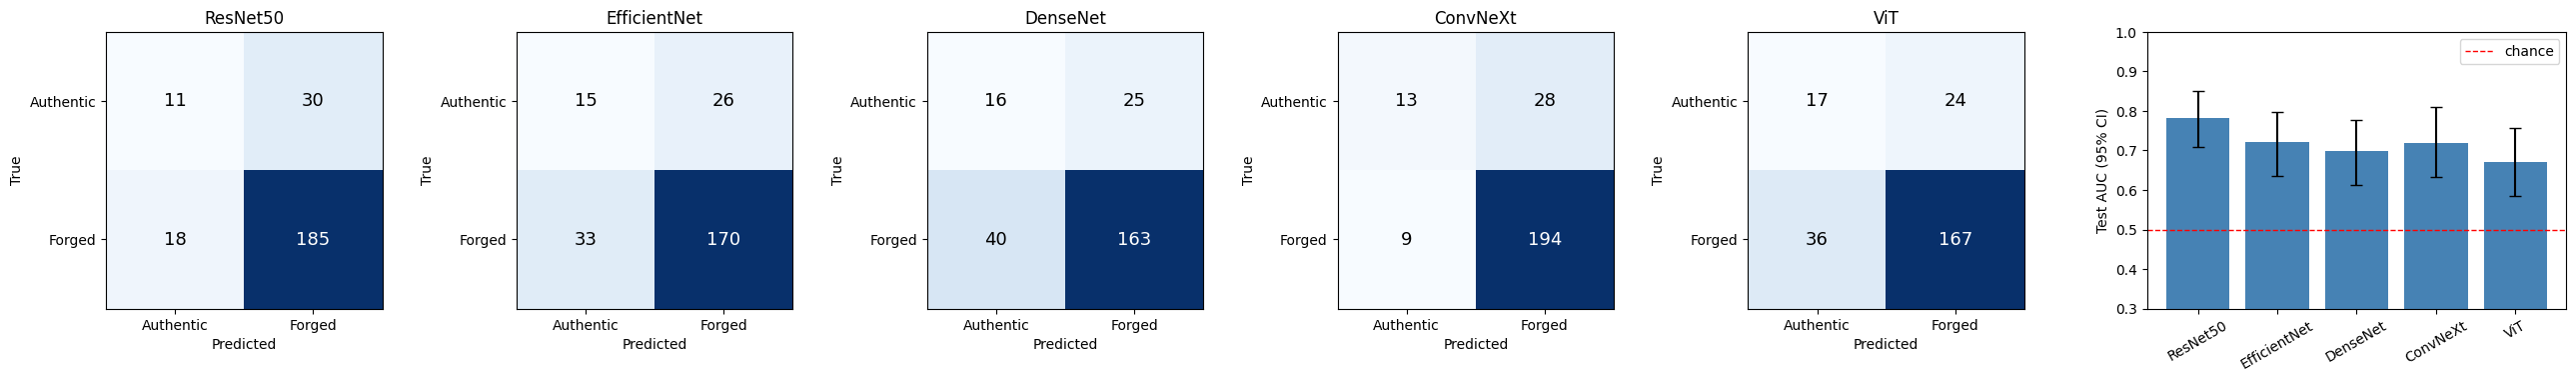


Best model by test AUC: ResNet50 (AUC 0.783, BalancedAcc 0.590, threshold 0.54, epoch 10)
Saved -> /kaggle/working/best_overall_model.pth
Note: picking the best model on the same test set makes this choice slightly optimistic.

Ranking by AUC: ResNet50 (0.783) > EfficientNet (0.721) > ConvNeXt (0.720) > DenseNet (0.698) > ViT (0.672)


In [10]:
import pickle
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import roc_auc_score

with open("/kaggle/working/results_patch.pkl", "rb") as f:
    results = pickle.load(f)
model_names = [n for n in ["ResNet50", "EfficientNet", "DenseNet", "ConvNeXt", "ViT"] if n in results]
print("Models found:", model_names)

# ---------------- Metrics from raw scores ----------------
def calc(scores, y, thr):
    pred = (scores >= thr).astype(int)
    tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec  = tp / (tp + fn) if tp + fn else 0.0
    spec = tn / (tn + fp) if tn + fp else 0.0
    f1   = 2 * tp / (2 * tp + fp + fn) if tp else 0.0
    f1_a = 2 * tn / (2 * tn + fn + fp) if tn else 0.0
    out = {"Accuracy": (tp + tn) / len(y), "Precision": prec, "Recall": rec, "F1": f1,
           "Dice": f1, "BalancedAcc": (rec + spec) / 2, "MacroF1": (f1 + f1_a) / 2,
           "AUC": roc_auc_score(y, scores)}
    return out, np.array([[tn, fp], [fn, tp]])

metric_cols = ["Accuracy", "Precision", "Recall", "F1", "Dice", "BalancedAcc", "MacroF1", "AUC"]
rng = np.random.default_rng(42)
N_BOOT = 2000

point, ci, cms = {}, {}, {}
for n in model_names:
    scores, y = np.load(f"/kaggle/working/{n}_test_scores.npy")
    y = y.astype(int)
    thr = results[n]["Threshold"]
    point[n], cms[n] = calc(scores, y, thr)

    # sanity: recomputed numbers must match what training stored
    assert abs(point[n]["F1"] - results[n]["F1"]) < 1e-6, f"{n}: F1 mismatch"
    assert (cms[n] == results[n]["ConfMatrix"]).all(), f"{n}: confusion matrix mismatch"

    boots = {k: [] for k in metric_cols}
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(y), len(y))
        if len(np.unique(y[idx])) < 2:
            continue
        b, _ = calc(scores[idx], y[idx], thr)
        for k in metric_cols:
            boots[k].append(b[k])
    ci[n] = {k: (np.percentile(v, 2.5), np.percentile(v, 97.5)) for k, v in boots.items()}
print("Sanity check passed: recomputed metrics match the stored results.\n")

# ---------------- Comparison table ----------------
rows = []
for n in model_names:
    r = {"Model": n, "Threshold": round(results[n]["Threshold"], 2)}
    for k in metric_cols:
        r[k] = f"{point[n][k]:.3f} [{ci[n][k][0]:.2f}-{ci[n][k][1]:.2f}]"
    rows.append(r)

# reference row: trivial classifier that always says "Forged"
y_ref = np.load(f"/kaggle/working/{model_names[0]}_test_scores.npy")[1].astype(int)
n_pos, n_neg = int(y_ref.sum()), int((1 - y_ref).sum())
rows.append({"Model": "(ref) always predict Forged", "Threshold": "-", "Accuracy": f"{n_pos/len(y_ref):.3f}",
             "Precision": f"{n_pos/len(y_ref):.3f}", "Recall": "1.000", "F1": f"{2*n_pos/(2*n_pos+n_neg):.3f}",
             "Dice": f"{2*n_pos/(2*n_pos+n_neg):.3f}", "BalancedAcc": "0.500", "MacroF1": "-", "AUC": "0.500"})

table = pd.DataFrame(rows)
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 20)
print("TEST-SET COMPARISON (value [95% bootstrap CI]; image-level; Forged = positive class)")
print(table.to_string(index=False))
table.to_csv("/kaggle/working/comparison_table.csv", index=False)

# ---------------- Confusion matrices + AUC plot ----------------
k = len(model_names)
fig, axes = plt.subplots(1, k + 1, figsize=(4.2 * k + 5, 3.8), gridspec_kw={"width_ratios": [1] * k + [1.4]})
for ax, n in zip(axes[:k], model_names):
    cm = cms[n]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(n)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Authentic", "Forged"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Authentic", "Forged"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)

aucs = [point[n]["AUC"] for n in model_names]
err = [[point[n]["AUC"] - ci[n]["AUC"][0] for n in model_names], [ci[n]["AUC"][1] - point[n]["AUC"] for n in model_names]]
axes[k].bar(model_names, aucs, yerr=err, capsize=4, color="steelblue")
axes[k].axhline(0.5, color="red", ls="--", lw=1, label="chance")
axes[k].set_ylim(0.3, 1.0); axes[k].set_ylabel("Test AUC (95% CI)"); axes[k].legend()
axes[k].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("/kaggle/working/comparison.png", dpi=150)
plt.show()

# ---------------- Best model (by test AUC) ----------------
best = max(model_names, key=lambda n: point[n]["AUC"])
ckpt = torch.load(f"/kaggle/working/best_{best}_patch.pth", map_location="cpu")
ckpt["model_name"] = best
torch.save(ckpt, "/kaggle/working/best_overall_model.pth")
print(f"\nBest model by test AUC: {best} (AUC {point[best]['AUC']:.3f}, BalancedAcc {point[best]['BalancedAcc']:.3f}, "
      f"threshold {results[best]['Threshold']:.2f}, epoch {ckpt['epoch']})")
print("Saved -> /kaggle/working/best_overall_model.pth")
print("Note: picking the best model on the same test set makes this choice slightly optimistic.")

ranked = sorted(model_names, key=lambda n: -point[n]["AUC"])
print("\nRanking by AUC:", " > ".join(f"{n} ({point[n]['AUC']:.3f})" for n in ranked))

Cell 9: Final bundle and download link
Refreshes results_bundle.zip so it includes the comparison table, the plot and the best model, and prints a download link.

In [11]:
from IPython.display import FileLink
make_bundle()
FileLink("/kaggle/working/results_bundle.zip")

Bundle updated: /kaggle/working/results_bundle.zip | 18 files | 235.0 MB


/kaggle/working/results_bundle.zip